# 11 - Digital Filter A/B Comparison

**Objective:** Compare the unfiltered pipeline (A) with the causal 80 Hz high-pass pipeline (B) on the SAME frozen v1 splits, same final architecture and hyperparameters, seeds 42/1/2 (`models/ab_filter_experiment.py`; results in `reports/ab_filter_results.json`). The v1 model in `models/final` is untouched.

In [1]:
import sys, os
from pathlib import Path
ML_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ML_ROOT / 'preprocessing'))
sys.path.insert(0, str(ML_ROOT / 'scripts'))
sys.path.insert(0, str(ML_ROOT / 'models'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
FIG_DIR = ML_ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
print('ML_ROOT =', ML_ROOT)


ML_ROOT = /Users/kireeti/Desktop/Projects/RESQ/SECURE-FOREST-PATROL/ml


In [2]:
import json
res = json.load(open(ML_ROOT/'reports'/'ab_filter_results.json'))
C = ['background','chainsaw','gunshot']
rows = []
for k, r in res.items():
    v, seed = k.split('_seed')
    for split in ['val','test','external']:
        m = r[split]
        rows.append(dict(variant=v, seed=int(seed), split=split, macro_f1=m['macro_f1'], bg_f1=m['per_class_f1']['background'],
            chainsaw_f1=m['per_class_f1']['chainsaw'], gunshot_f1=m['per_class_f1']['gunshot'],
            chainsaw_recall=m['per_class_recall']['chainsaw'], gunshot_recall=m['per_class_recall']['gunshot']))
df = pd.DataFrame(rows)
df.round(3)

,variant,seed,split,macro_f1,bg_f1,chainsaw_f1,gunshot_f1,chainsaw_recall,gunshot_recall
0,A,42,val,0.629,0.885,0.630,0.373,0.613,0.815
1,A,42,test,0.455,0.691,0.515,0.159,0.868,0.907
2,A,42,external,0.313,0.354,0.316,0.268,0.883,0.976
3,A,1,val,0.617,0.885,0.625,0.339,0.545,0.852
4,A,1,test,0.468,0.691,0.577,0.134,0.847,0.953
5,A,1,external,0.362,0.447,0.340,0.298,0.906,1.000
6,A,2,val,0.543,0.873,0.455,0.300,0.336,0.759
7,A,2,test,0.469,0.715,0.561,0.132,0.715,0.953
8,A,2,external,0.402,0.546,0.393,0.266,0.941,1.000
9,B,42,val,0.550,0.846,0.515,0.289,0.473,0.870


## Mean +/- std over seeds

In [3]:
summ = df.groupby(['split','variant']).agg(['mean','std']).drop(columns='seed').round(3)
summ

macro_f1         bg_f1        chainsaw_f1        gunshot_f1  \
                     mean    std   mean    std        mean    std       mean   
split    variant                                                               
external A          0.359  0.045  0.449  0.096       0.350  0.039      0.277   
         B          0.404  0.102  0.443  0.169       0.176  0.085      0.592   
test     A          0.464  0.008  0.699  0.014       0.551  0.033      0.141   
         B          0.399  0.072  0.580  0.133       0.443  0.083      0.173   
val      A          0.596  0.047  0.881  0.007       0.570  0.100      0.338   
         B          0.612  0.083  0.870  0.041       0.587  0.163      0.380   

                        chainsaw_recall        gunshot_recall         
                    std            mean    std           mean    std  
split    variant                                                      
external A        0.018           0.910  0.029          0.992  0.014  
         B        0.224           0.405  0.134          0.935  0.075  
test     A        0.015           0.810  0.083          0.938  0.027  
         B        0.055           0.866  0.029          0.891  0.128  
val      A        0.036           0.498  0.144          0.809  0.047  
         B        0.078           0.611  0.198          0.772  0.093

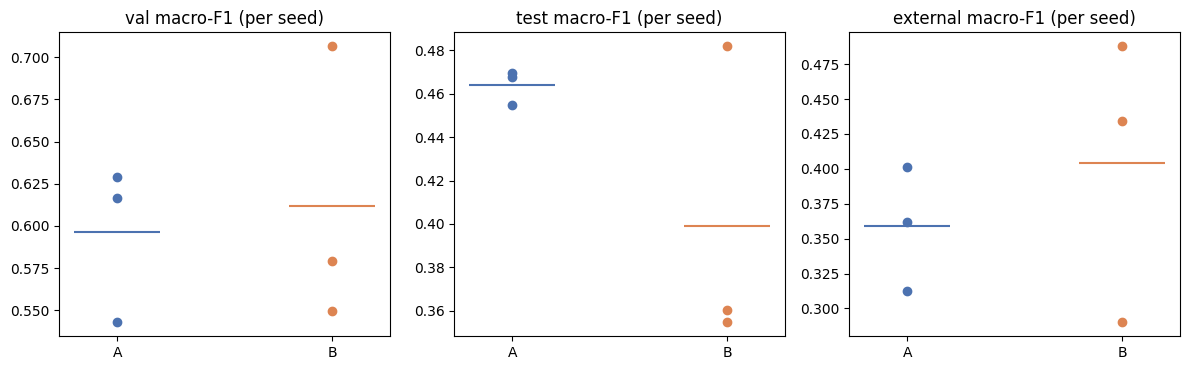

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12,3.8))
for ax, split in zip(axes, ['val','test','external']):
    d = df[df.split==split]
    for v, c in [('A','#4C72B0'),('B','#DD8452')]:
        x = d[d.variant==v]; ax.scatter([v]*len(x), x.macro_f1, c=c); ax.hlines(x.macro_f1.mean(), -.2 if v=='A' else .8, .2 if v=='A' else 1.2, colors=c)
    ax.set_title(f'{split} macro-F1 (per seed)')
plt.tight_layout(); plt.savefig(FIG_DIR/'11_filter_ab_macro_f1.png', dpi=120); plt.show()

## Robustness (INT8 model, clean / 15 dB / 5 dB feature-domain noise on test_v1)

In [5]:
rob = []
for k, r in res.items():
    v, seed = k.split('_seed')
    for lvl, m in r['robustness'].items():
        rob.append(dict(variant=v, seed=int(seed), level=lvl, acc=m['accuracy'], macro_f1=m['macro_f1']))
rob = pd.DataFrame(rob)
rob.groupby(['level','variant'])[['acc','macro_f1']].agg(['mean','std']).round(3)

acc        macro_f1       
                   mean    std     mean    std
level    variant                              
clean    A        0.598  0.020    0.468  0.005
         B        0.506  0.125    0.408  0.075
moderate A        0.556  0.090    0.306  0.029
         B        0.392  0.238    0.244  0.144
strong   A        0.755  0.116    0.323  0.038
         B        0.110  0.056    0.067  0.029

## Conclusion

See `reports/FILTER_REPORT.md` for the measured verdict. The comparison above is over three seeds per variant; differences smaller than the seed-to-seed standard deviation should be read as neutral.